# Importación de librerías:
## pandas: importación y manipulación de datos
## numpy: cálculos numéricos y operaciones con arrays multidimensionales
## matplotlib.pyplot: visualización de gráficos
## seaborn: visualización estadística avanzada basada en matplotlib
## torch: creación y entrenamiento de redes neuronales
## train_test_split: divide los datos en entrenamiento y validación
## StandardScaler: normalización de características numéricas
## accuracy_score, f1_score, confusion_matrix, classification_report: métricas de evaluación
## RobertaTokenizer, RobertaModel: tokenización y modelo RoBERTa preentrenado (para extracción de características)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from transformers import RobertaModel, RobertaTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import pandas as pd
from tqdm import tqdm
import pickle
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

In [3]:
data = pd.read_csv("reviews_22052025_2400.csv")

In [4]:
data.rename(columns={'classification': 'Cluster'}, inplace=True)

# Se convierte Genuine en 1 y Fake en 0

In [5]:
df = data[['text','review_count_user', 'average_stars_user', 'yelping_days',
    'useful', 'funny', 'cool', 'fans', 'Cluster']]

# Configuraicón del modelo

In [ ]:
class Config:
    def __init__(self):
        self.bert_model_name = 'roberta-base'
        self.max_length = 128
        self.batch_size = 8
        self.learning_rate = 2e-5
        self.weight_decay = 0.01
        self.epochs = 20
        self.num_user_features = 7
        self.hidden_size = 64
        self.num_layers = 1
        self.num_filters = 64
        self.filter_sizes = [2, 3, 4]
        self.dropout_prob = 0.5
        self.max_grad_norm = 0.8
        self.warmup_ratio = 0.1
        self.classes = ['fake', 'real']

config = Config()

# Se etiqueta el campo Cluster

In [ ]:
tokenizer = RobertaTokenizer.from_pretrained(config.bert_model_name)
texts = df['text'].tolist()
labels = df['Cluster'].tolist()

# División de datos

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=42)

# Tokenizacion final

In [ ]:
def tokenize(texts):
    return tokenizer(texts, padding=True, truncation=True, return_tensors="pt", max_length=config.max_length)

train_inputs = tokenize(train_texts)
test_inputs = tokenize(test_texts)

# Escalado de caracteristicas del usuario

In [ ]:
user_features = ['review_count_user', 'average_stars_user', 'yelping_days', 'useful', 'funny', 'cool', 'fans']
train_indices = df[df['text'].isin(train_texts)].index
test_indices = df[df['text'].isin(test_texts)].index

scaler = StandardScaler()
train_user = scaler.fit_transform(df.loc[train_indices, user_features].values)
test_user = scaler.transform(df.loc[test_indices, user_features].values)

# Conversion de etiquetas a tensores

In [ ]:
train_features = torch.tensor(train_user).float().unsqueeze(1)
test_features = torch.tensor(test_user).float().unsqueeze(1)
train_labels = torch.tensor(train_labels).long()
test_labels = torch.tensor(test_labels).long()

# Carga de datos

In [ ]:
train_dataset = TensorDataset(train_inputs['input_ids'], train_inputs['attention_mask'], train_features, train_labels)
test_dataset = TensorDataset(test_inputs['input_ids'], test_inputs['attention_mask'], test_features, test_labels)
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size)

# Modelo RoBERTa + mCNN + sBiGRU con atencion

In [ ]:
class DualAttentionRoberta_mCNN_sBiGRU(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(config.bert_model_name)
        self.roberta_hidden_size = self.roberta.config.hidden_size

        self.convs = nn.ModuleList([
            nn.Conv1d(self.roberta_hidden_size, config.num_filters, kernel_size=fs)
            for fs in config.filter_sizes
        ])
        self.fc_cnn = nn.Linear(len(config.filter_sizes) * config.num_filters, config.hidden_size * 2)

        self.sBiGRU = nn.GRU(
            input_size=config.num_user_features,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            bidirectional=True,
            batch_first=True
        )

        self.attention_user = nn.Sequential(
            nn.Linear(config.hidden_size * 2, config.hidden_size),
            nn.Tanh(),
            nn.Linear(config.hidden_size, 1, bias=False)
        )

        self.attention_text = nn.Sequential(
            nn.Linear(self.roberta_hidden_size, config.hidden_size),
            nn.Tanh(),
            nn.Linear(config.hidden_size, 1, bias=False)
        )

        self.fc_combined = nn.Linear(config.hidden_size * 4, len(config.classes))
        self.dropout = nn.Dropout(config.dropout_prob)
        self.layer_norm = nn.LayerNorm(config.hidden_size * 4)

    def forward(self, input_ids, attention_mask, user_features):
        roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_states = roberta_output.last_hidden_state

        text_att_weights = torch.softmax(self.attention_text(last_hidden_states), dim=1)
        text_out = torch.sum(text_att_weights * last_hidden_states, dim=1)

        x_conv = last_hidden_states.permute(0, 2, 1)
        conv_outputs = [torch.relu(conv(x_conv)).max(dim=2).values for conv in self.convs]
        cnn_output = torch.cat(conv_outputs, dim=1)
        cnn_output = torch.relu(self.fc_cnn(cnn_output))

        gru_output, _ = self.sBiGRU(user_features)
        user_att_weights = torch.softmax(self.attention_user(gru_output), dim=1)
        user_out = torch.sum(user_att_weights * gru_output, dim=1)

        combined = torch.cat((cnn_output, user_out), dim=1)
        combined = self.layer_norm(combined)
        combined = self.dropout(combined)

        logits = self.fc_combined(combined)
        return logits

# --- FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        else:
            loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

# Entrenamiento y Ejecución

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1: 100%|██████████| 185/185 [00:05<00:00, 31.46it/s]


Epoch 1 - Loss: 0.3541
              precision    recall  f1-score   support

        fake       0.54      0.90      0.68       196
        real       0.56      0.14      0.23       174

    accuracy                           0.54       370
   macro avg       0.55      0.52      0.45       370
weighted avg       0.55      0.54      0.47       370



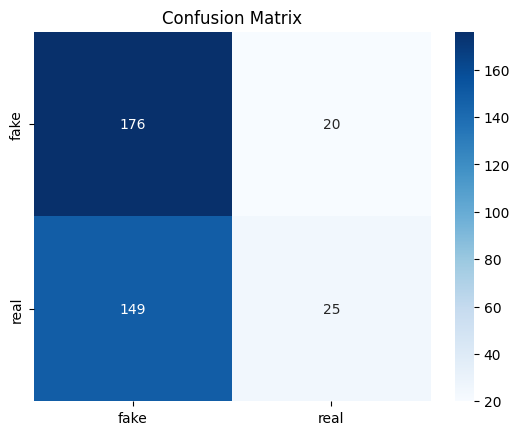

Modelo guardado!


Epoch 2: 100%|██████████| 185/185 [00:05<00:00, 33.19it/s]


Epoch 2 - Loss: 0.3088
              precision    recall  f1-score   support

        fake       0.58      0.79      0.67       196
        real       0.61      0.37      0.46       174

    accuracy                           0.59       370
   macro avg       0.60      0.58      0.57       370
weighted avg       0.60      0.59      0.57       370



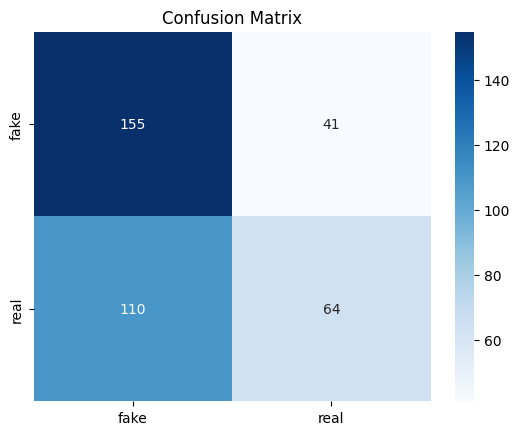

Modelo guardado!


Epoch 3: 100%|██████████| 185/185 [00:05<00:00, 32.98it/s]


Epoch 3 - Loss: 0.2851
              precision    recall  f1-score   support

        fake       0.60      0.83      0.70       196
        real       0.66      0.37      0.47       174

    accuracy                           0.61       370
   macro avg       0.63      0.60      0.58       370
weighted avg       0.63      0.61      0.59       370



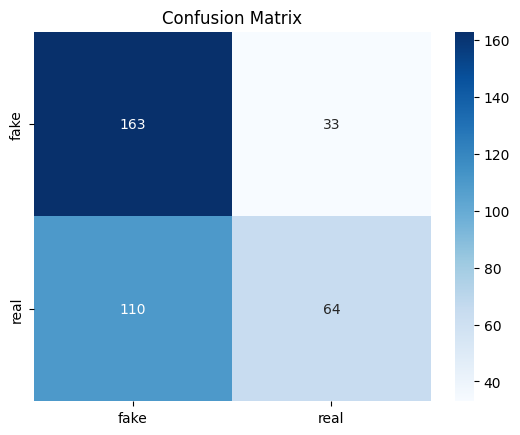

Modelo guardado!
RoBERTa descongelado en época 4


Epoch 4: 100%|██████████| 185/185 [00:24<00:00,  7.69it/s]


Epoch 4 - Loss: 0.2628
              precision    recall  f1-score   support

        fake       0.83      0.46      0.59       196
        real       0.60      0.89      0.71       174

    accuracy                           0.66       370
   macro avg       0.71      0.68      0.65       370
weighted avg       0.72      0.66      0.65       370



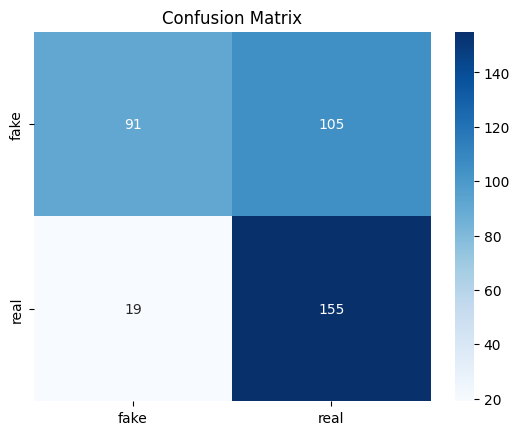

Modelo guardado!


Epoch 5: 100%|██████████| 185/185 [00:24<00:00,  7.65it/s]


Epoch 5 - Loss: 0.2413
              precision    recall  f1-score   support

        fake       0.72      0.62      0.67       196
        real       0.63      0.72      0.67       174

    accuracy                           0.67       370
   macro avg       0.67      0.67      0.67       370
weighted avg       0.68      0.67      0.67       370



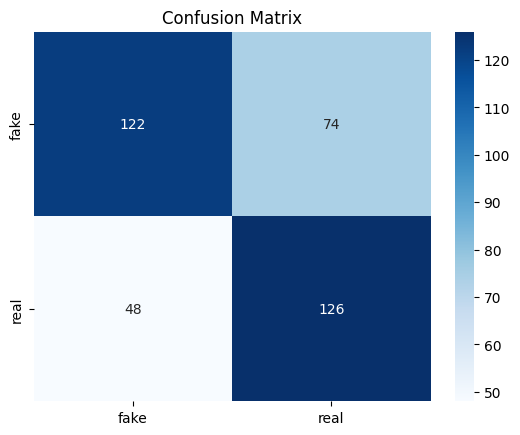

Modelo guardado!


Epoch 6: 100%|██████████| 185/185 [00:24<00:00,  7.59it/s]


Epoch 6 - Loss: 0.1935
              precision    recall  f1-score   support

        fake       0.75      0.69      0.72       196
        real       0.68      0.74      0.71       174

    accuracy                           0.71       370
   macro avg       0.71      0.71      0.71       370
weighted avg       0.71      0.71      0.71       370



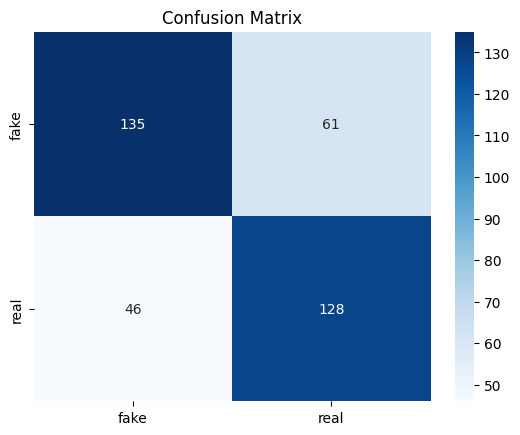

Modelo guardado!


Epoch 7: 100%|██████████| 185/185 [00:24<00:00,  7.62it/s]


Epoch 7 - Loss: 0.1609
              precision    recall  f1-score   support

        fake       0.72      0.76      0.74       196
        real       0.71      0.66      0.68       174

    accuracy                           0.71       370
   macro avg       0.71      0.71      0.71       370
weighted avg       0.71      0.71      0.71       370



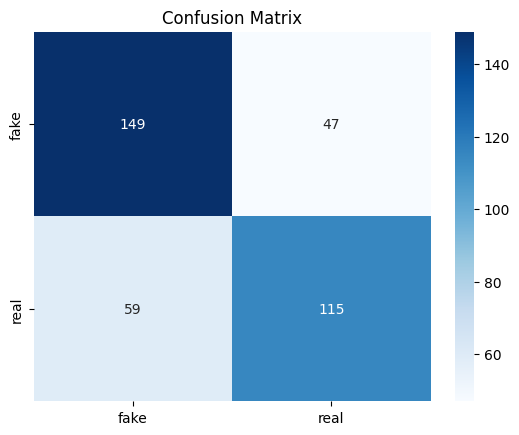

Modelo guardado!


Epoch 8: 100%|██████████| 185/185 [00:24<00:00,  7.60it/s]


Epoch 8 - Loss: 0.1718
              precision    recall  f1-score   support

        fake       0.79      0.64      0.71       196
        real       0.67      0.80      0.73       174

    accuracy                           0.72       370
   macro avg       0.73      0.72      0.72       370
weighted avg       0.73      0.72      0.72       370



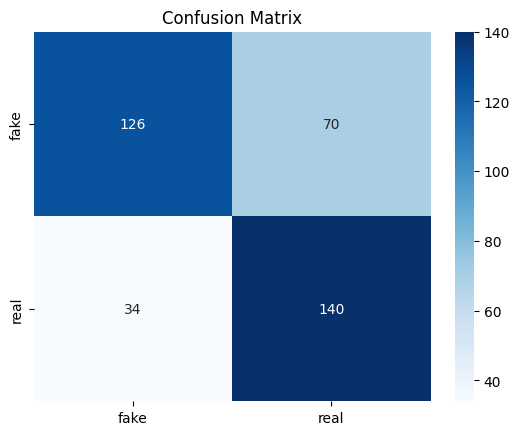

Modelo guardado!


Epoch 9: 100%|██████████| 185/185 [00:24<00:00,  7.59it/s]


Epoch 9 - Loss: 0.1417
              precision    recall  f1-score   support

        fake       0.72      0.64      0.68       196
        real       0.64      0.71      0.67       174

    accuracy                           0.68       370
   macro avg       0.68      0.68      0.68       370
weighted avg       0.68      0.68      0.68       370



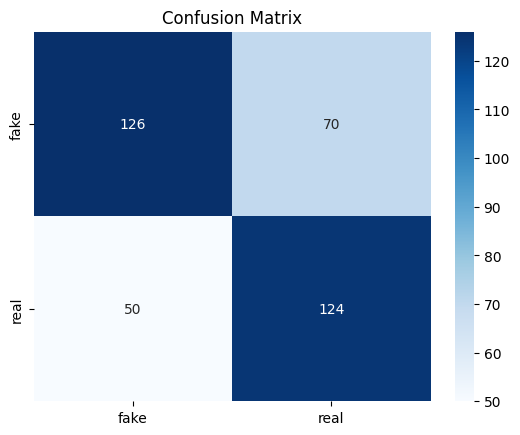

Epoch 10: 100%|██████████| 185/185 [00:24<00:00,  7.58it/s]


Epoch 10 - Loss: 0.1039
              precision    recall  f1-score   support

        fake       0.75      0.73      0.74       196
        real       0.71      0.72      0.72       174

    accuracy                           0.73       370
   macro avg       0.73      0.73      0.73       370
weighted avg       0.73      0.73      0.73       370



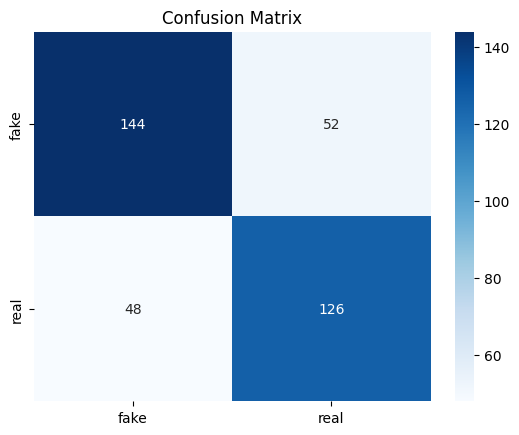

Modelo guardado!


Epoch 11: 100%|██████████| 185/185 [00:25<00:00,  7.20it/s]


Epoch 11 - Loss: 0.0545
              precision    recall  f1-score   support

        fake       0.75      0.67      0.71       196
        real       0.67      0.75      0.71       174

    accuracy                           0.71       370
   macro avg       0.71      0.71      0.71       370
weighted avg       0.71      0.71      0.71       370



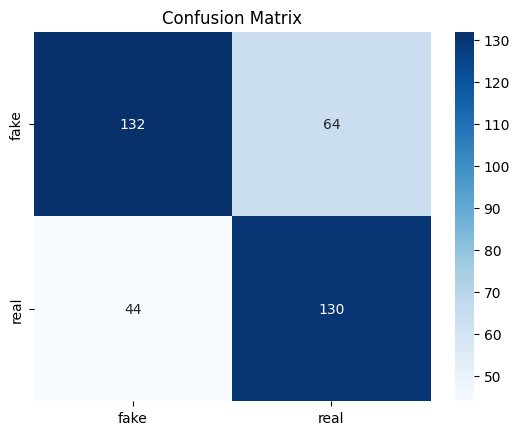

Epoch 12: 100%|██████████| 185/185 [00:25<00:00,  7.22it/s]


Epoch 12 - Loss: 0.0141
              precision    recall  f1-score   support

        fake       0.72      0.77      0.74       196
        real       0.72      0.67      0.69       174

    accuracy                           0.72       370
   macro avg       0.72      0.72      0.72       370
weighted avg       0.72      0.72      0.72       370



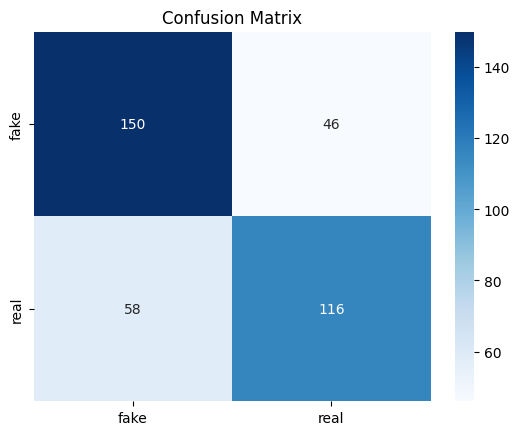

Early stopping activado!


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DualAttentionRoberta_mCNN_sBiGRU(config).to(device)

freeze_epochs = 3
for param in model.roberta.parameters():
    param.requires_grad = False

classes_np = np.array([0, 1])
class_weights_np = compute_class_weight(class_weight='balanced', classes=classes_np, y=df['Cluster'].values)
class_weights_np[0] *= 1.8
class_weights_np[1] *= 1.0
alpha = torch.tensor(class_weights_np, dtype=torch.float).to(device)

criterion = FocalLoss(alpha=alpha, gamma=2.0)
optimizer = AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

best_f1 = 0
patience = 2
early_stop_counter = 0

for epoch in range(1, config.epochs + 1):
    if epoch == freeze_epochs + 1:
        for param in model.roberta.parameters():
            param.requires_grad = True
        print(f"RoBERTa descongelado en época {epoch}")

    model.train()
    losses = []
    for input_ids, att_mask, user_feat, labels in tqdm(train_loader, desc=f"Epoch {epoch}"):
        input_ids, att_mask = input_ids.to(device), att_mask.to(device)
        user_feat, labels = user_feat.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(input_ids, att_mask, user_feat)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())

    print(f"Epoch {epoch} - Loss: {np.mean(losses):.4f}")

    # --- EVALUATION ---
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for input_ids, att_mask, user_feat, labels in test_loader:
            input_ids, att_mask = input_ids.to(device), att_mask.to(device)
            user_feat, labels = user_feat.to(device), labels.to(device)
            outputs = model(input_ids, att_mask, user_feat)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = (probs >= 0.45).long()
            preds_all.append(preds.cpu())
            labels_all.append(labels.cpu())

    preds_all = torch.cat(preds_all).numpy()
    labels_all = torch.cat(labels_all).numpy()

    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average='macro')
    print(classification_report(labels_all, preds_all, target_names=config.classes))
    cm = confusion_matrix(labels_all, preds_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=config.classes, yticklabels=config.classes)
    plt.title('Confusion Matrix')
    plt.show()

    if f1 > best_f1:
        best_f1 = f1
        early_stop_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print("Modelo guardado!")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping activado!")
            break

# 